# Disease Prediction using Classification Algorithm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('imported')

imported


In [2]:
# load the dataset
data=pd.read_csv('/content/Breast_cancer_dataset.csv')
print('imported')

imported


In [3]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [4]:
data['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
data.drop(['Unnamed: 32','id'],axis=1,inplace=True)

In [7]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
data['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


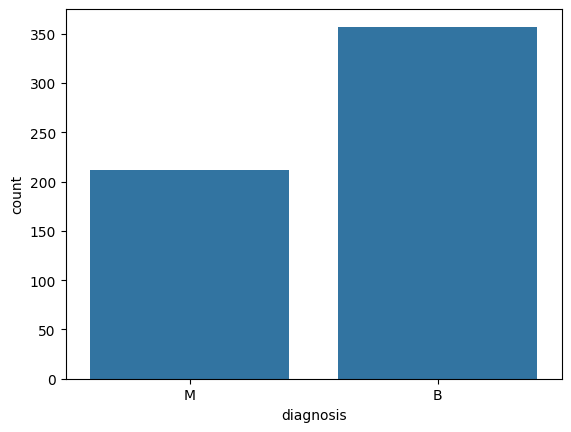

In [9]:
sns.countplot(x=data['diagnosis'])
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['diagnosis']=encoder.fit_transform(data['diagnosis'])
data['diagnosis']

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


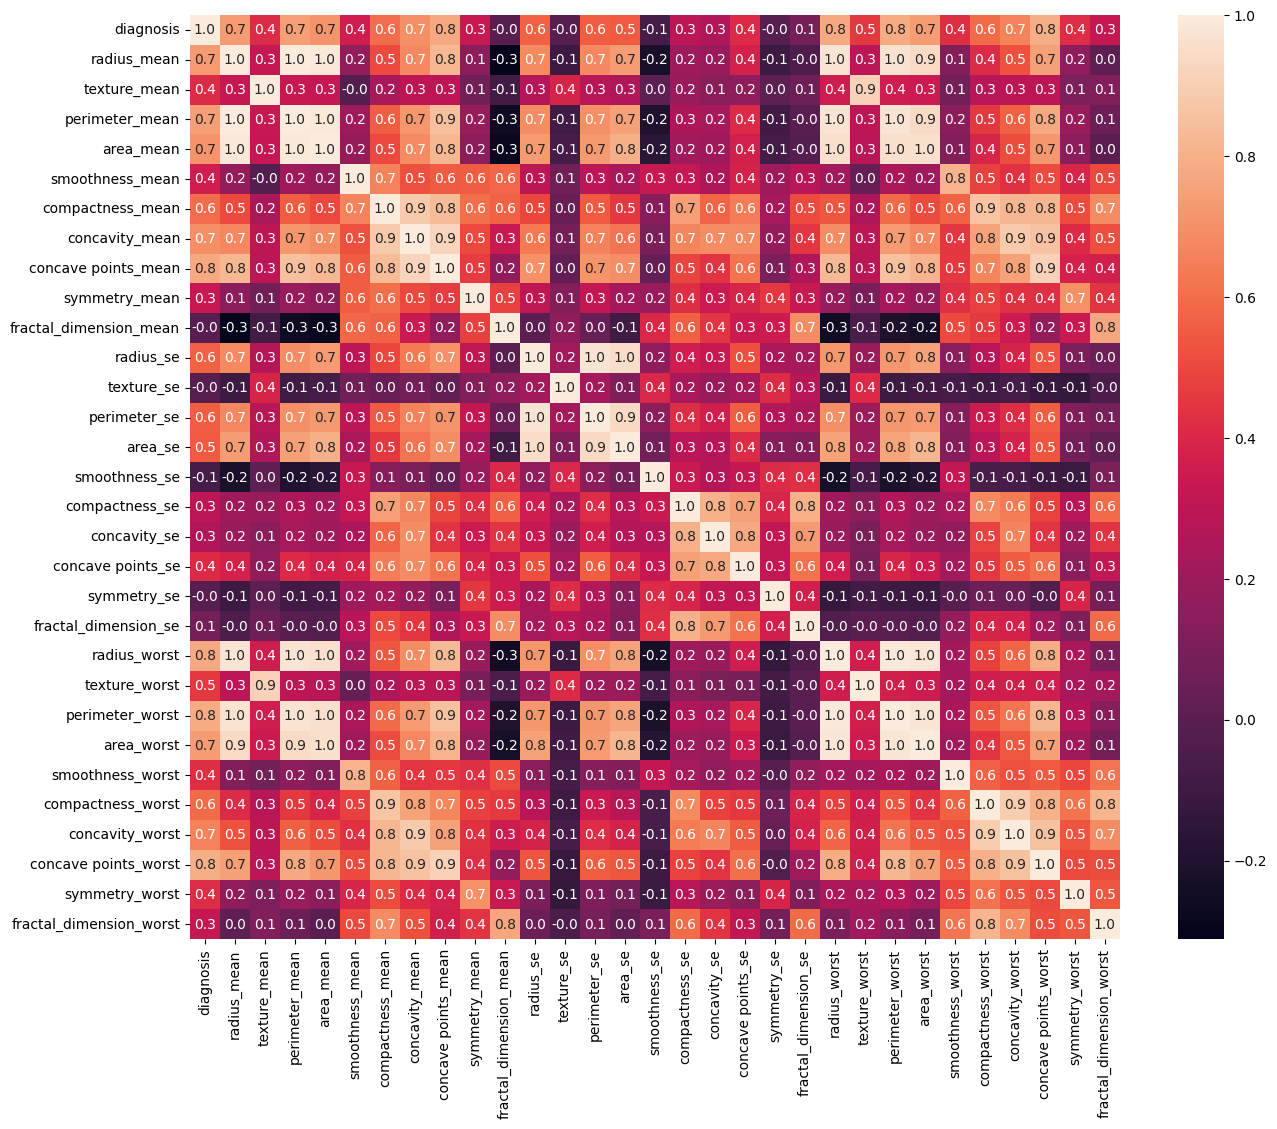

In [11]:
# Visualize the corr
plt.figure(figsize=(15,12))
sns.heatmap(data.corr(numeric_only=True),annot=True,fmt='.1f')
plt.show()

# Apply Machine Learning

In [12]:
data.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [13]:
#create indep var & dep var
X=data.drop('diagnosis',axis=1)
y=data['diagnosis']

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [16]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


# Combine sequence of operations
## pipeline --Preprocessing & model training

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
print('imported')

imported


In [18]:
pipeline=Pipeline([('scaler',StandardScaler()),
                   ('log_reg',LogisticRegression(max_iter=10000,random_state=42))])

pipeline.fit(X_train,y_train)
print('Training Completed')

Training Completed


In [19]:
y_pred=pipeline.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1])

In [20]:
y_pred_test_prob=pipeline.predict_proba(X_test)[:,1]
y_pred_test_prob

array([1.13590250e-01, 9.99990991e-01, 9.96920905e-01, 5.10134225e-04,
       6.06389713e-05, 1.00000000e+00, 9.99999998e-01, 9.65096937e-01,
       3.79342140e-01, 7.59402734e-04, 4.98717826e-02, 9.87592879e-01,
       6.07381873e-03, 8.56069117e-01, 1.62175599e-03, 9.99259818e-01,
       1.85245908e-03, 1.11662359e-05, 8.18375684e-07, 9.99998883e-01,
       8.41633901e-02, 9.74778299e-03, 9.99999996e-01, 7.89186669e-05,
       1.13874333e-03, 5.84587240e-04, 1.07444521e-03, 5.97518345e-03,
       2.85311713e-03, 9.99991817e-01, 5.17409813e-04, 1.48760128e-04,
       2.16094439e-03, 5.49413839e-03, 1.40706288e-04, 2.42334266e-03,
       9.42415985e-01, 2.89870352e-03, 9.99911214e-01, 4.81363757e-02,
       7.12433090e-05, 9.99593392e-01, 2.46640626e-03, 9.63884505e-04,
       1.99892051e-02, 7.15547342e-02, 3.98571939e-04, 4.90625569e-04,
       3.04698010e-02, 6.14016147e-04, 9.99879654e-01, 9.99999947e-01,
       3.08211520e-01, 1.32293769e-02, 2.73627242e-05, 9.54524359e-03,
      

In [21]:
result_df=pd.DataFrame({'Actual_label':y_test,'Pred_Label':y_pred,'Pred_prob':y_pred_test_prob})

In [22]:
result_df

,Actual_label,Pred_Label,Pred_prob
204,0,0,0.113590
70,1,1,0.999991
131,1,1,0.996921
431,0,0,0.000510
540,0,0,0.000061
...,...,...,...
486,0,0,0.032195
75,1,1,0.999323
249,0,0,0.001308
238,0,1,0.542700


In [23]:
y_test.value_counts()

,count
diagnosis,
0,71
1,43


In [24]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[70  1]
 [ 2 41]]


In [25]:
print('Accuracy Score',accuracy_score(y_test,y_pred))

Accuracy Score 0.9736842105263158


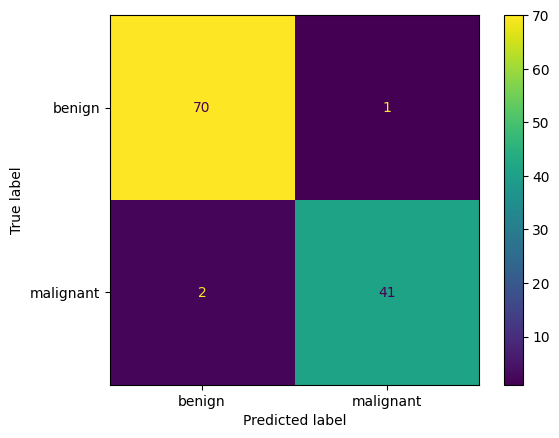

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['benign','malignant'])
cm_display.plot()
plt.show()

In [27]:
# print classification report
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report
print('Precision Score',precision_score(y_test,y_pred))
print('Recall Score',recall_score(y_test,y_pred))
print('F1 Score',f1_score(y_test,y_pred))


Precision Score 0.9761904761904762
Recall Score 0.9534883720930233
F1 Score 0.9647058823529412


In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [29]:
import joblib
joblib.dump(pipeline,'pipeline.pkl')
print('Model saved')

Model saved


In [30]:
# do prediction
import joblib
model=joblib.load('/content/pipeline.pkl')
print('Model loaded')


Model loaded


In [31]:
y_pred_new=model.predict(X_test)
print('accuracy',accuracy_score(y_test,y_pred_new))

accuracy 0.9736842105263158


In [32]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)

In [33]:
data_new={"model":pipeline,
          "accuracy":accuracy,
          "recall":recall,
          "precision":precision}
import pickle
with open('data_new.pkl','wb') as file:
  pickle.dump(data_new,file)

In [34]:
# load the data
import pickle
with open('/content/data_new.pkl','rb') as file:
  data_new=pickle.load(file)

# print accuracy
print(data_new['accuracy'])
print(data_new['recall'])
print(data_new['precision'])

0.9736842105263158
0.9534883720930233
0.9761904761904762


## ROC-AUC curve

In [35]:
# calculate ROC
from sklearn.metrics import roc_curve,auc
fpr,tpr,thresh=roc_curve(y_test,y_pred_test_prob)

In [36]:
auc_score=auc(fpr,tpr)
print('AUC Score',auc_score)

AUC Score 0.99737962659679


In [37]:
print(thresh)

[           inf 1.00000000e+00 7.76680319e-01 5.42699821e-01
 4.84826685e-01 1.13099081e-01 8.41633901e-02 8.18375684e-07]


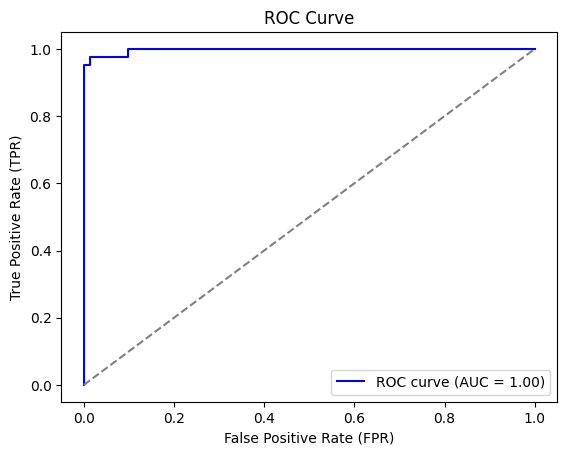

In [38]:
# plot the curve

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random guessing line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [39]:

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresh[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

Optimal Threshold: 0.4848


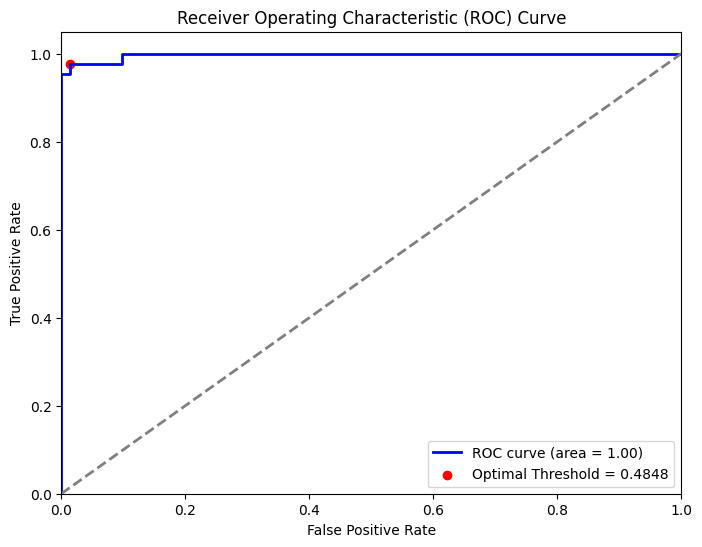

In [40]:
# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Apply Naive Bayes Classifier

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
print('imported')

imported


In [42]:
pipeline=Pipeline([('scaler',StandardScaler()),
                  ('nb',GaussianNB())])

pipeline.fit(X_train,y_train)
print('Training completed')

Training completed


In [43]:
y_pred=pipeline.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [44]:
#Predict on the training and testing set
y_pred_train_nb = pipeline.predict(X_train)
y_pred_test_nb = pipeline.predict(X_test)
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report
# Calculate the training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_nb)
testing_accuracy = accuracy_score(y_test, y_pred_test_nb)
print("\nNaïve Bayes:")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")


Naïve Bayes:
Training Accuracy: 0.9362637362637363
Testing Accuracy: 0.9649122807017544


In [45]:
y_pred_prob_nb = pipeline.predict_proba(X_test)[:, 1]

In [46]:
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_nb,
    'Predicted Probability': y_pred_prob_nb
})

results_df.head()

,Actual Label,Predicted Label,Predicted Probability
204,0,0,1.349483e-09
70,1,1,1.000000e+00
131,1,1,1.000000e+00
431,0,0,9.801091e-12
540,0,0,8.102568e-15


Confusion Matrix:
[[70  1]
 [ 3 40]]


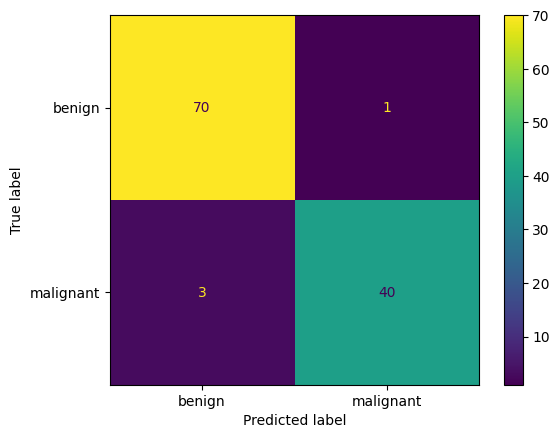

In [47]:
# Print confusion matrix

conf_matrix_nb = confusion_matrix(y_test, y_pred_test_nb)
print("Confusion Matrix:")
print(conf_matrix_nb)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_nb, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()

In [48]:
# Print classification report
print("\t\tNaïve Bayes Classification Report:")
print("\t\t-----------------------------------")
print(classification_report(y_test, y_pred_test_nb))

		Naïve Bayes Classification Report:
		-----------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Optimal Threshold: 0.0126


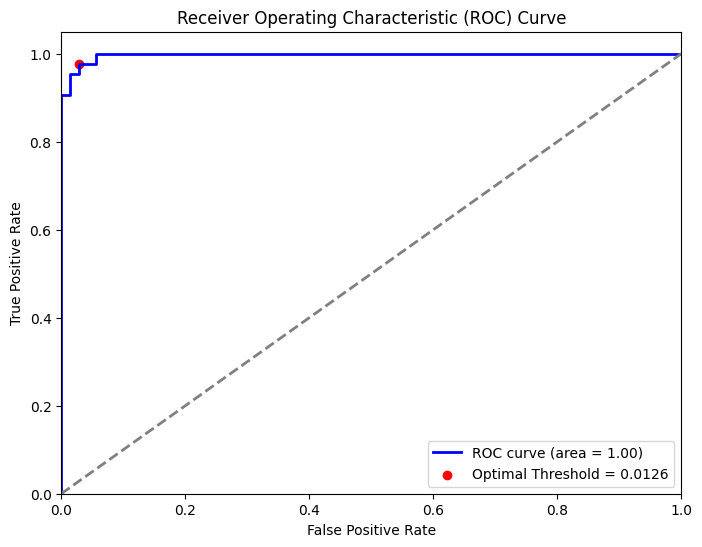

In [49]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_nb)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Issues
1. Multiply many small probabilties--log prob, add them
2. if any p=0 --smoothing

## Apply KNN Classifier

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
print('imported')

imported


In [88]:
pipeline=Pipeline([('scaler',StandardScaler()),
                  ('knn',KNeighborsClassifier(n_neighbors=7))])

pipeline.fit(X_train,y_train)
print('Training completed')

Training completed


In [82]:
#Predict on the training and testing set
y_pred_train_knn = pipeline.predict(X_train)
y_pred_test_knn = pipeline.predict(X_test)
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report
# Calculate the training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_knn)
testing_accuracy = accuracy_score(y_test, y_pred_test_knn)
print("\nKNN:")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")


KNN:
Training Accuracy: 0.9692307692307692
Testing Accuracy: 0.9473684210526315


Confusion Matrix:
[[68  3]
 [ 3 40]]


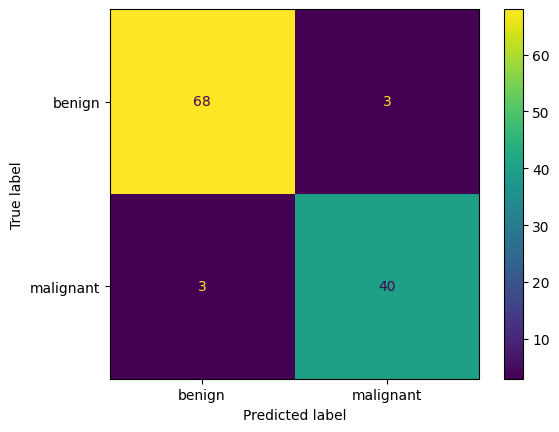

In [54]:

conf_matrix_nb = confusion_matrix(y_test, y_pred_test_knn)
print("Confusion Matrix:")
print(conf_matrix_nb)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_nb, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()

In [56]:
# Print classification report
print("\t\t KNN Classification Report:")
print("\t\t-----------------------------------")
print(classification_report(y_test, y_pred_test_knn))

		 KNN Classification Report:
		-----------------------------------
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [57]:
y_pred_prob_knn = pipeline.predict_proba(X_test)[:, 1]

Optimal Threshold: 0.4000


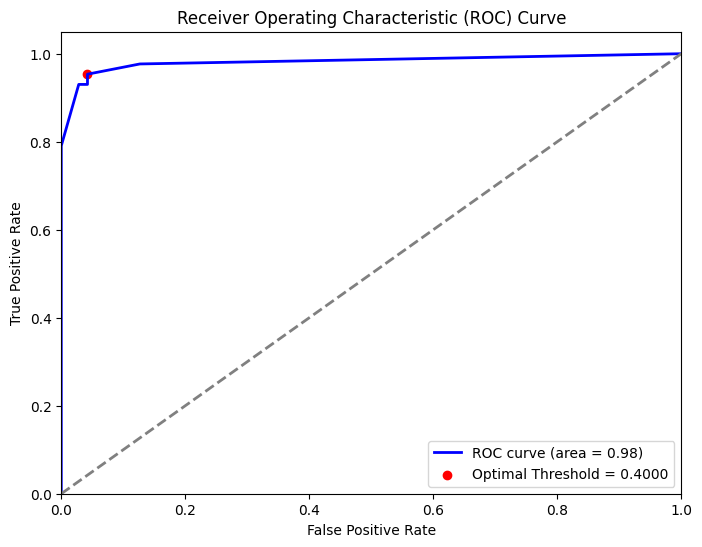

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_knn)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## GridSearchCV

1. Algo -to find best hyperparameters of a model by testing all parameters combinations and evaluating them using Cross-Validation.

2. Exhaustive Search ---Try all combinations(Grid Search)

3. For each combination evaluate the model-->Perform Cross Validation

4. Compute Avg score

5. Select best set of HP

In [94]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'knn__n_neighbors': np.arange(1, 21)}

# Create a pipeline with a scaler and KNN classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),    # Standardize the data
    ('knn', KNeighborsClassifier())  # KNN classifier
])

In [95]:

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=10, scoring='accuracy')

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Get the best k value
optimal_k = grid_search.best_params_['knn__n_neighbors']
print(f"The optimal number of neighbors is {optimal_k}")

# Get the best score
best_score = grid_search.best_score_
print(f"The best cross-validated accuracy is {best_score}")

# Get the cross-validation results
cv_results = grid_search.cv_results_

The optimal number of neighbors is 7
The best cross-validated accuracy is 0.9713526570048309


In [85]:
cv_results['mean_test_score']

array([0.94067633, 0.94714976, 0.96043478, 0.9626087 , 0.96695652,
       0.9647343 , 0.97135266, 0.96033816, 0.9647343 , 0.96038647,
       0.9626087 , 0.95821256, 0.95381643, 0.95821256, 0.95821256,
       0.95821256, 0.95821256, 0.95603865, 0.95603865, 0.95381643])

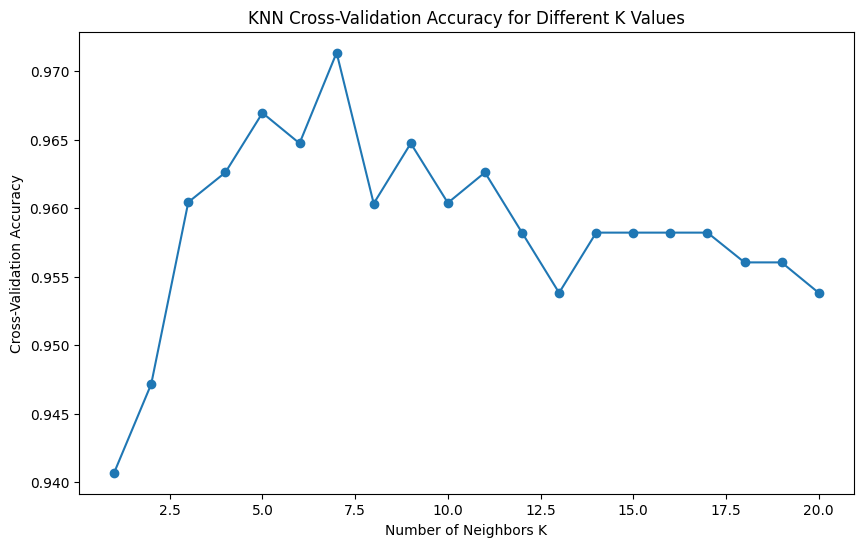

In [84]:
# Plot the cross-validation accuracy for different k values
plt.figure(figsize=(10, 6))
plt.plot(param_grid['knn__n_neighbors'], cv_results['mean_test_score'], marker='o')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Accuracy for Different K Values')
plt.show()

In [86]:
from sklearn.model_selection import GridSearchCV

# define parameters
parameter_grid={'KNN__n_neighbors':np.arange(1,21),
                'KNN__metric':['minkowski'],
                'KNN__p':[1,2]}

pipeline=Pipeline([('scaler',StandardScaler()),
                  ('KNN',KNeighborsClassifier())])

grid_search=GridSearchCV(pipeline,param_grid=parameter_grid,cv=10,scoring='accuracy')

grid_search.fit(X_train,y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('KNN', KNeighborsClassifier())]),
             param_grid={'KNN__metric': ['minkowski'],
                         'KNN__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20]),
                         'KNN__p': [1, 2]},
             scoring='accuracy')

In [87]:
param=grid_search.best_params_
print(param)

{'KNN__metric': 'minkowski', 'KNN__n_neighbors': np.int64(7), 'KNN__p': 2}
